# GPT Constraint Ablation

A focused notebook for the CauseNet synthetic-desc GPT-5-mini constraint ablation. It starts with the copy-pasteable ablation table, then reproduces the data-constraint-quality x LLM-constraint-quality interaction plots for GPT constraints and the original Gemini constraints.

In [1]:
from pathlib import Path
import math
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from IPython.display import Markdown, display

if Path.cwd().name == 'notebooks':
    REPO_ROOT = Path.cwd().resolve().parent
else:
    REPO_ROOT = Path.cwd().resolve()

RESULTS_DIR = REPO_ROOT / 'results'
PAPER_TAG = 'g2a01'
TABLE_PATH = RESULTS_DIR / 'tables' / f'gemini_gpt5_structural_{PAPER_TAG}.md'

RUNS = {
    'Gemini constraints': RESULTS_DIR / 'ABAPC-LLM' / f'merged_synthetic-desc_{PAPER_TAG}.csv',
    'GPT-5-mini constraints': RESULTS_DIR / 'ABAPC-LLM' / f'merged_synthetic-desc-gpt5mini_{PAPER_TAG}.csv',
}
GPT_CONSENSUS = RESULTS_DIR / 'llm_constraints' / 'synthetic-desc-gpt5mini-consensus.json'


## Ablation Table

This is the table to paste into Markdown. It uses the matched dataset intersection across the compared methods. Rerun with [link](..\scripts\comparison_table.py).

| Group   |   Datasets | ABAPC-LLM F1    | ABAPC-LLM-gpt5mini F1   | ABAPC F1        | MPC-LLM F1      | MPC-LLM-gpt5mini F1   | MPC F1          | ABAPC-LLM SHD   | ABAPC-LLM-gpt5mini SHD   | ABAPC SHD       | MPC-LLM SHD      | MPC-LLM-gpt5mini SHD   | MPC SHD          |
|:--------|-----------:|:----------------|:------------------------|:----------------|:----------------|:----------------------|:----------------|:----------------|:-------------------------|:----------------|:-----------------|:-----------------------|:-----------------|
| Overall |         43 | 0.708 +/- 0.154 | 0.690 +/- 0.136         | 0.639 +/- 0.115 | 0.489 +/- 0.158 | 0.435 +/- 0.121       | 0.373 +/- 0.096 | 4.820 +/- 3.300 | 4.955 +/- 3.356          | 5.348 +/- 3.339 | 8.155 +/- 4.754  | 8.963 +/- 4.714        | 10.302 +/- 4.766 |
| \|V\|=5   |         15 | 0.821 +/- 0.174 | 0.758 +/- 0.188         | 0.669 +/- 0.134 | 0.666 +/- 0.084 | 0.549 +/- 0.118       | 0.463 +/- 0.089 | 1.247 +/- 1.075 | 1.597 +/- 1.294          | 2.090 +/- 1.103 | 2.616 +/- 0.695  | 3.610 +/- 1.121        | 5.005 +/- 0.997  |
| \|V\|=10  |         14 | 0.633 +/- 0.126 | 0.648 +/- 0.086         | 0.608 +/- 0.128 | 0.412 +/- 0.094 | 0.398 +/- 0.053       | 0.354 +/- 0.045 | 5.940 +/- 2.052 | 5.892 +/- 2.390          | 6.273 +/- 2.729 | 9.122 +/- 2.240  | 10.059 +/- 2.595       | 11.016 +/- 2.503 |
| \|V\|=15  |         14 | 0.661 +/- 0.070 | 0.658 +/- 0.077         | 0.637 +/- 0.069 | 0.375 +/- 0.084 | 0.350 +/- 0.072       | 0.296 +/- 0.055 | 7.529 +/- 2.398 | 7.616 +/- 2.702          | 7.912 +/- 2.648 | 13.122 +/- 2.121 | 13.601 +/- 2.491       | 15.264 +/- 2.573 |

In [2]:
if TABLE_PATH.exists():
    display(Markdown(TABLE_PATH.read_text(encoding='utf-8')))
else:
    display(Markdown(f'Missing `{TABLE_PATH}`. Run `python scripts/paper_tables.py --tag {PAPER_TAG}` after the GPT/MPC jobs finish.'))
print(TABLE_PATH)


| Group   | Datasets | ABAPC-LLM F1    | ABAPC-LLM-gpt5mini F1 | ABAPC F1        | MPC-LLM F1      | MPC-LLM-gpt5mini F1 | MPC F1          | ABAPC-LLM SHD   | ABAPC-LLM-gpt5mini SHD | ABAPC SHD       | MPC-LLM SHD     | MPC-LLM-gpt5mini SHD | MPC SHD         |
| ------- | -------- | --------------- | --------------------- | --------------- | --------------- | ------------------- | --------------- | --------------- | ---------------------- | --------------- | --------------- | -------------------- | --------------- |
| Overall | 43       | 0.711 +/- 0.150 | 0.691 +/- 0.138       | 0.637 +/- 0.112 | 0.718 +/- 0.166 | 0.669 +/- 0.160     | 0.602 +/- 0.129 | 4.807 +/- 3.309 | 4.899 +/- 3.260        | 5.368 +/- 3.289 | 4.960 +/- 3.369 | 5.554 +/- 3.279      | 6.345 +/- 3.080 |
| |V|=5   | 15       | 0.828 +/- 0.168 | 0.755 +/- 0.195       | 0.663 +/- 0.144 | 0.822 +/- 0.201 | 0.713 +/- 0.235     | 0.592 +/- 0.176 | 1.186 +/- 0.972 | 1.604 +/- 1.314        | 2.127 +/- 1.176 | 1.328 +/- 1.154 | 2.213 +/- 1.750      | 3.395 +/- 1.495 |
| |V|=10  | 14       | 0.633 +/- 0.112 | 0.655 +/- 0.093       | 0.605 +/- 0.110 | 0.634 +/- 0.122 | 0.621 +/- 0.095     | 0.574 +/- 0.095 | 5.984 +/- 2.056 | 5.755 +/- 2.329        | 6.345 +/- 2.631 | 6.197 +/- 2.224 | 6.630 +/- 2.144      | 7.173 +/- 2.165 |
| |V|=15  | 14       | 0.663 +/- 0.068 | 0.658 +/- 0.067       | 0.641 +/- 0.063 | 0.691 +/- 0.099 | 0.671 +/- 0.095     | 0.640 +/- 0.096 | 7.508 +/- 2.377 | 7.575 +/- 2.455        | 7.863 +/- 2.586 | 7.616 +/- 2.415 | 8.059 +/- 2.439      | 8.677 +/- 2.629 |


/vol/bitbucket/fr920/ArgCausalDisco-worktrees/llm-uai2026-freeze/results/tables/gemini_gpt5_structural_g2a01.md


In [3]:
# Coverage sanity check for the GPT ablation.
all_bifs = sorted(path.stem for path in (REPO_ROOT / 'synthetic').glob('*.bifxml'))
consensus = pd.read_json(GPT_CONSENSUS)
consensus['forbidden_n'] = consensus['priors'].map(lambda p: len((p or {}).get('forbidden', [])))
consensus['required_n'] = consensus['priors'].map(lambda p: len((p or {}).get('required', [])))
consensus['empty_prior'] = (consensus['forbidden_n'] == 0) & (consensus['required_n'] == 0)

gpt_abapc = pd.read_csv(RUNS['GPT-5-mini constraints'])
gpt_new_datasets = set(gpt_abapc.loc[gpt_abapc['impl'].eq('new'), 'dataset'])

print(f"BIFXML graphs: {len(all_bifs)}")
print(f"GPT consensus rows: {len(consensus)}")
print(f"GPT empty consensus priors: {int(consensus['empty_prior'].sum())}")
print(f"ABAPC-LLM GPT datasets present: {len(gpt_new_datasets)}")
print('\nEmpty-prior datasets skipped by ABAPC-LLM GPT:')
for name in sorted(consensus.loc[consensus['empty_prior'], 'filename']):
    print(f"- {name}")


BIFXML graphs: 54
GPT consensus rows: 54
GPT empty consensus priors: 11
ABAPC-LLM GPT datasets present: 43

Empty-prior datasets skipped by ABAPC-LLM GPT:
- dag_10_nodes_10_edges_semantics_ER
- dag_10_nodes_10_edges_semantics_random
- dag_10_nodes_15_edges_degrees_ER
- dag_10_nodes_15_edges_none_ER
- dag_15_nodes_15_edges_none_ER
- dag_15_nodes_15_edges_none_SF
- dag_15_nodes_22_edges_none_ER
- dag_15_nodes_22_edges_semantics_SF
- dag_5_nodes_5_edges_degrees_ER
- dag_5_nodes_5_edges_semantics_ER
- dag_5_nodes_7_edges_degrees_SF


## Interaction Analysis

The heatmaps reproduce the original interaction analysis with the GPT constraint file. The x-axis is data constraint quality (`CIT_F1` when available), the y-axis is LLM constraint quality, and the cell value is mean Δ DAG F1: `ABAPC-LLM - ABAPC`.

In [4]:
def cmap_blue_good_orange_bad():
    return LinearSegmentedColormap.from_list(
        'good_blue_bad_orange',
        [(255 / 255, 140 / 255, 0 / 255), (1, 1, 1), (0 / 255, 90 / 255, 181 / 255)],
        N=256,
    )


def tie_safe_qbins(series, q=3, right=True):
    s = pd.to_numeric(series, errors='coerce')
    ranks = s.rank(method='first')
    norm = ranks / (ranks.max() if ranks.max() else 1)
    edges = np.quantile(norm, np.linspace(0, 1, q + 1))
    if right:
        edges[-1] = 1.0
    labels = ['Low', 'Mid', 'High'][:q]
    bins = pd.cut(norm, bins=edges, labels=labels, include_lowest=True, right=right, duplicates='drop')
    return bins, edges


def grid_counts_and_means(df_in, row_labcol, col_labcol, val_col):
    rows = ['High', 'Mid', 'Low']
    cols = ['Low', 'Mid', 'High']
    means = np.full((3, 3), np.nan)
    counts = np.zeros((3, 3), dtype=int)
    for i, rlab in enumerate(rows):
        for j, clab in enumerate(cols):
            vals = df_in.loc[(df_in[row_labcol] == rlab) & (df_in[col_labcol] == clab), val_col].astype(float)
            if len(vals) > 0:
                means[i, j] = float(vals.mean())
                counts[i, j] = int(len(vals))
    return means, counts


def parse_synth_fields(name: str):
    size = None
    gtype = 'other'
    density = None
    m = re.search(r'_(\d+)_nodes', name)
    size = int(m.group(1)) if m else None
    if 'ER' in name:
        gtype = 'ER'
    elif 'SF' in name:
        gtype = 'SF'
    elif 'random' in name.lower():
        gtype = 'LT'
    m2 = re.search(r'_(\d+)_edges', name)
    if m2 and size:
        edges = int(m2.group(1))
        ratio = edges / float(size)
        if abs(ratio - 1.0) < 0.2:
            density = '1d'
        elif abs(ratio - 1.5) < 0.3:
            density = '1.5d'
        else:
            density = f'{ratio:.1f}d'
    return size, gtype, density


def build_run_table(csv_path: Path):
    df_raw = pd.read_csv(csv_path).copy()
    if {'prior_forbidden_F1', 'prior_required_F1'} <= set(df_raw.columns):
        df_raw['prior_overall_F1'] = df_raw[['prior_forbidden_F1', 'prior_required_F1']].mean(axis=1)

    llm_col = next(
        (col for col in ['prior_overall_F1', 'AP_F1', 'prior_required_F1', 'prior_forbidden_F1', 'prior_forbidden_Precision', 'AP'] if col in df_raw.columns),
        None,
    )
    if llm_col is None:
        raise ValueError(f'No LLM-quality column found in {csv_path}')

    def row_ciq(row):
        if 'CIT_F1' in row and pd.notna(row['CIT_F1']):
            return row['CIT_F1']
        p = row.get('CIT_Precision')
        r = row.get('CIT_Recall')
        if pd.notna(p) and pd.notna(r) and (p + r) > 0:
            return 2 * p * r / (p + r)
        if pd.notna(r):
            return r
        if pd.notna(p):
            return p
        return np.nan

    df_raw['CIQ'] = df_raw.apply(row_ciq, axis=1).clip(0, 1)
    keep = ['dataset', 'seed', 'impl', 'num_nodes', 'CIQ', llm_col, 'dag_F1']
    avg = df_raw[keep].groupby(['dataset', 'seed', 'impl'], as_index=False).mean(numeric_only=True)

    org = avg[avg['impl'] == 'org'].drop(columns=['impl']).rename(columns={'CIQ': 'ci_quality'})
    new = avg[avg['impl'] == 'new'].drop(columns=['impl']).rename(columns={'CIQ': 'ci_quality_new', llm_col: 'llm_quality'})
    merged = pd.merge(new, org, on=['dataset', 'seed'], how='inner', suffixes=('_new', '_org'))
    merged['n_nodes'] = merged['num_nodes_new'].fillna(merged['num_nodes_org'])

    result = merged[['dataset', 'seed', 'n_nodes', 'ci_quality', 'llm_quality', 'dag_F1_new', 'dag_F1_org']].copy()
    result = result.rename(columns={'dag_F1_new': 'comb', 'dag_F1_org': 'ci'})
    result['delta'] = result['comb'] - result['ci']
    result = result.dropna(subset=['ci_quality', 'llm_quality', 'delta'])

    parsed = result['dataset'].apply(parse_synth_fields)
    result['size'] = [item[0] for item in parsed]
    result['type'] = [item[1] for item in parsed]
    result['density'] = [item[2] for item in parsed]
    return result


In [5]:
def plot_single_heatmap(means, counts, title, ax=None, vmax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(6.8, 5.4))
    if vmax is None:
        vmax = np.nanmax(np.abs(means)) if np.any(~np.isnan(means)) else 1.0
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    im = ax.imshow(means, cmap=cmap_blue_good_orange_bad(), norm=norm, aspect='equal')
    ax.set_xticks(range(3)); ax.set_xticklabels(['Low CI', 'Mid CI', 'High CI'], fontsize=12)
    ax.set_yticks(range(3)); ax.set_yticklabels(['High LLM', 'Mid LLM', 'Low LLM'], fontsize=12)
    ax.set_xlabel('Data constraint F1', fontsize=12)
    ax.set_ylabel('LLM constraint F1', fontsize=12)
    ax.set_title(title, fontsize=13)
    for i in range(3):
        for j in range(3):
            if not np.isnan(means[i, j]):
                ax.text(j, i, f'{means[i, j]:.3f}\n(n={counts[i, j]})', ha='center', va='center', fontsize=11)
    return im


def run_interaction_heatmaps(csv_path: Path, run_label: str, split_by='size', global_bins=True):
    m = build_run_table(csv_path)
    if split_by not in {'dataset', 'size', 'type', 'density'}:
        raise ValueError("split_by must be one of: dataset, size, type, density")

    print(f'{run_label}: {len(m)} matched run rows, {m.dataset.nunique()} datasets')
    groups = sorted(m[split_by].dropna().unique().tolist())
    if global_bins:
        m['ci_bin'], ci_edges = tie_safe_qbins(m['ci_quality'], q=3, right=True)
        m['llm_bin'], llm_edges = tie_safe_qbins(m['llm_quality'], q=3, right=True)
        bin_cols = ('llm_bin', 'ci_bin')
        print('CI edges (rank space):', [float(x) for x in ci_edges])
        print('LLM edges (rank space):', [float(x) for x in llm_edges])
    else:
        m['ci_bin_agg'], _ = tie_safe_qbins(m['ci_quality'], q=3, right=True)
        m['llm_bin_agg'], _ = tie_safe_qbins(m['llm_quality'], q=3, right=True)
        bin_cols = ('llm_bin_agg', 'ci_bin_agg')

    agg_means, agg_counts = grid_counts_and_means(m, bin_cols[0], bin_cols[1], 'delta')
    vmax = np.nanmax(np.abs(agg_means)) if np.any(~np.isnan(agg_means)) else 1.0
    fig, ax = plt.subplots(figsize=(6.8, 5.4))
    im = plot_single_heatmap(agg_means, agg_counts, f'{run_label}: aggregated', ax=ax, vmax=vmax)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Mean Δ DAG F1')
    plt.show()

    ncols = 3
    nrows = math.ceil(len(groups) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.6 * ncols, 4.8 * nrows), squeeze=False)
    panel_vmax = 0.0
    panels = []
    for group in groups:
        sub = m[m[split_by] == group].copy()
        if not global_bins:
            sub['ci_bin'], _ = tie_safe_qbins(sub['ci_quality'], q=3, right=True)
            sub['llm_bin'], _ = tie_safe_qbins(sub['llm_quality'], q=3, right=True)
            row_bin, col_bin = 'llm_bin', 'ci_bin'
        else:
            row_bin, col_bin = bin_cols
        means, counts = grid_counts_and_means(sub, row_bin, col_bin, 'delta')
        panels.append((group, means, counts))
        if np.any(~np.isnan(means)):
            panel_vmax = max(panel_vmax, np.nanmax(np.abs(means)))
    panel_vmax = panel_vmax or 1.0

    last_im = None
    for idx, (group, means, counts) in enumerate(panels):
        ax = axes[idx // ncols][idx % ncols]
        last_im = plot_single_heatmap(means, counts, f'{split_by}={group}', ax=ax, vmax=panel_vmax)
    for idx in range(len(panels), nrows * ncols):
        axes[idx // ncols][idx % ncols].axis('off')
    if last_im is not None:
        fig.colorbar(last_im, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02, label='Mean Δ DAG F1')
    fig.suptitle(f'{run_label}: split by {split_by}', y=1.01, fontsize=14)
    plt.show()
    return m


## GPT-5-mini Constraints

In [6]:
gpt_table = build_run_table(RUNS['GPT-5-mini constraints'])
display(gpt_table.groupby(['size', 'type'])['delta'].agg(['count', 'mean', 'std']).reset_index())

,size,type,count,mean,std
0,5,ER,200,0.162702,0.179481
1,5,LT,300,0.096858,0.114555
2,5,SF,249,0.029286,0.237848
3,10,ER,150,0.022439,0.046672
4,10,LT,250,0.080220,0.106634
5,10,SF,300,0.009100,0.047851
6,15,ER,200,0.018136,0.055902
7,15,LT,300,0.021684,0.073058
8,15,SF,200,0.024911,0.042364


GPT-5-mini constraints: 2149 matched run rows, 43 datasets
CI edges (rank space): [0.00046533271288971617, 0.33364355514192645, 0.6668217775709633, 1.0]
LLM edges (rank space): [0.00046533271288971617, 0.33364355514192645, 0.6668217775709633, 1.0]


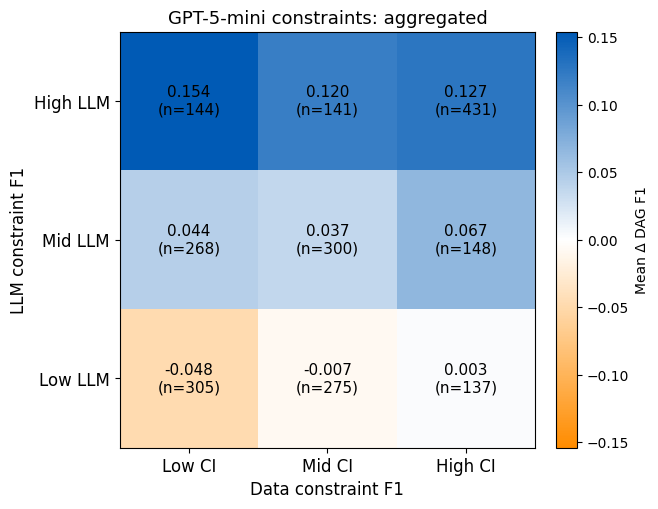

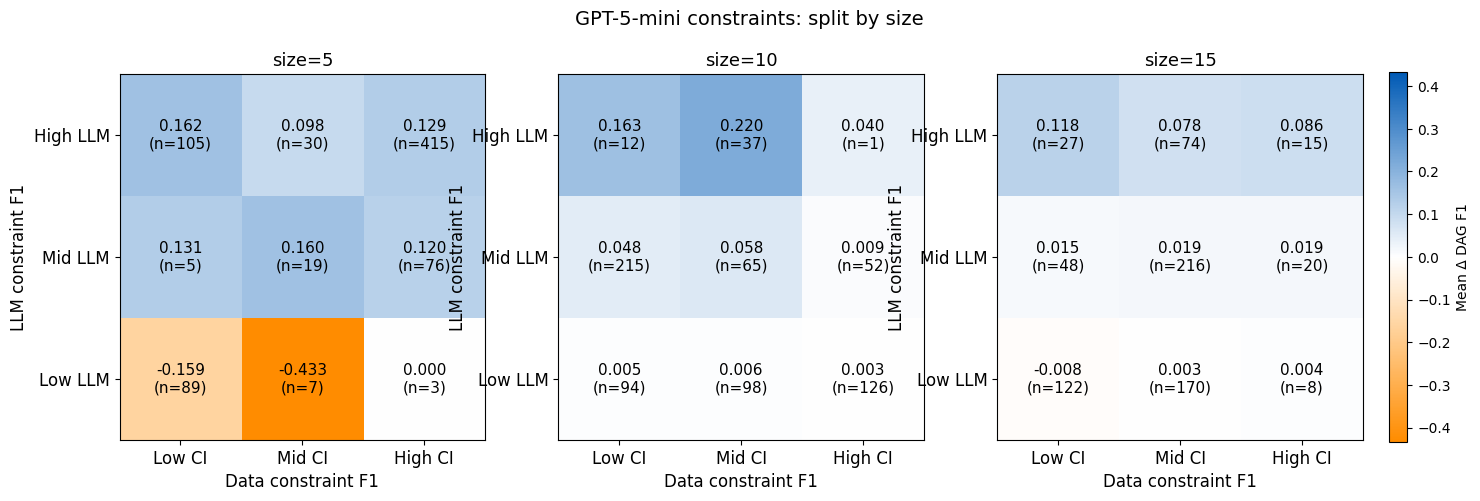

,dataset,seed,n_nodes,ci_quality,llm_quality,comb,ci,delta,size,type,density,ci_bin,llm_bin
0,dag_10_nodes_10_edges_degrees_ER,150,10.0,0.820084,0.012346,0.800000,0.82000,-0.020000,10,ER,1d,High,Low
1,dag_10_nodes_10_edges_degrees_ER,183,10.0,0.895833,0.012346,0.694720,0.63156,0.063160,10,ER,1d,High,Low
2,dag_10_nodes_10_edges_degrees_ER,304,10.0,0.793651,0.012346,0.821040,0.80000,0.021040,10,ER,1d,High,Low
3,dag_10_nodes_10_edges_degrees_ER,316,10.0,0.748663,0.012346,0.673680,0.54738,0.126300,10,ER,1d,Mid,Low
4,dag_10_nodes_10_edges_degrees_ER,359,10.0,0.813725,0.012346,0.778940,0.80000,-0.021060,10,ER,1d,High,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2145,dag_5_nodes_7_edges_semantics_random,8266,5.0,0.969072,0.271429,0.461533,0.43076,0.030773,5,LT,1.5d,High,High
2146,dag_5_nodes_7_edges_semantics_random,8289,5.0,0.677419,0.271429,0.583350,0.16670,0.416650,5,LT,1.5d,Mid,High
2147,dag_5_nodes_7_edges_semantics_random,8328,5.0,0.931034,0.271429,0.461533,0.49230,-0.030767,5,LT,1.5d,High,High
2148,dag_5_nodes_7_edges_semantics_random,8823,5.0,0.482759,0.271429,0.666700,0.75000,-0.083300,5,LT,1.5d,Mid,High


In [7]:
run_interaction_heatmaps(RUNS['GPT-5-mini constraints'], 'GPT-5-mini constraints', split_by='size', global_bins=True)

GPT-5-mini constraints: 2149 matched run rows, 43 datasets
CI edges (rank space): [0.00046533271288971617, 0.33364355514192645, 0.6668217775709633, 1.0]
LLM edges (rank space): [0.00046533271288971617, 0.33364355514192645, 0.6668217775709633, 1.0]


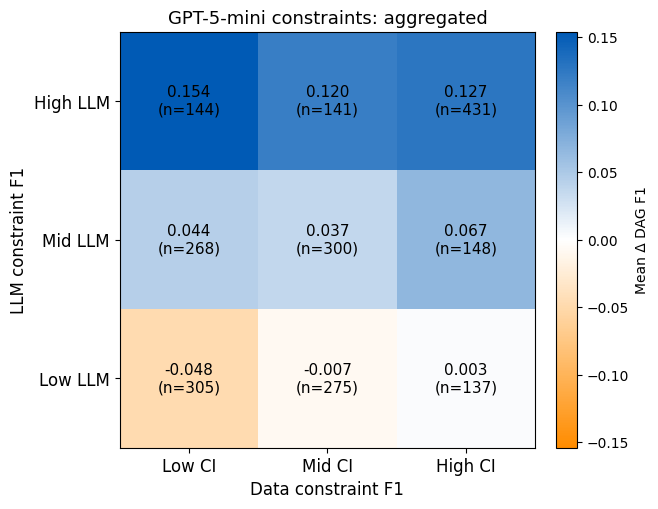

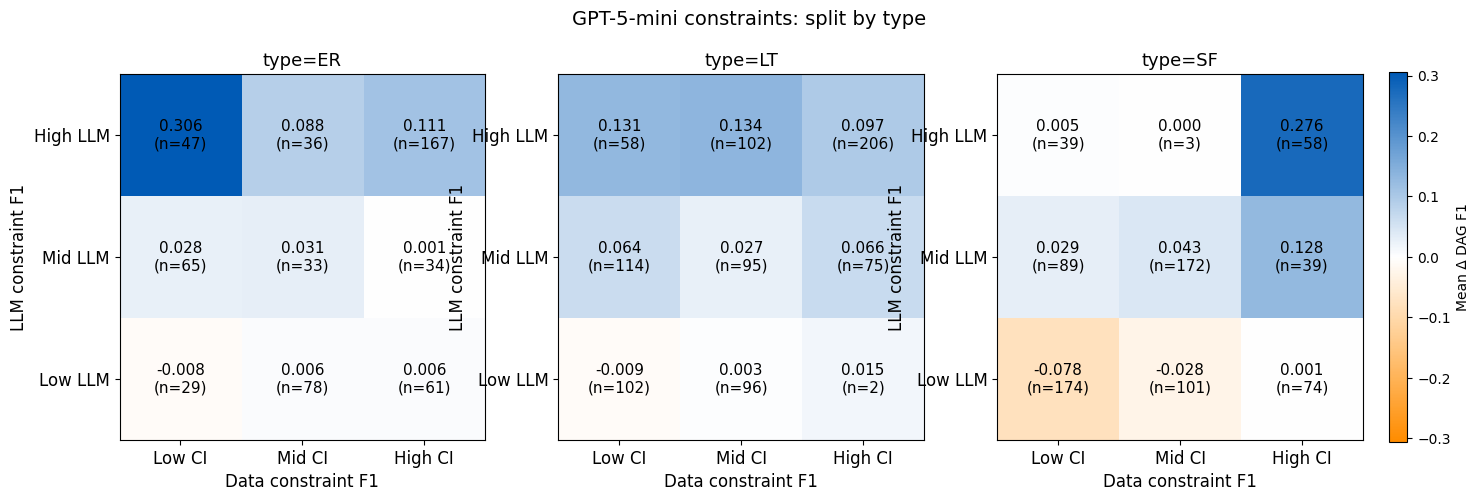

,dataset,seed,n_nodes,ci_quality,llm_quality,comb,ci,delta,size,type,density,ci_bin,llm_bin
0,dag_10_nodes_10_edges_degrees_ER,150,10.0,0.820084,0.012346,0.800000,0.82000,-0.020000,10,ER,1d,High,Low
1,dag_10_nodes_10_edges_degrees_ER,183,10.0,0.895833,0.012346,0.694720,0.63156,0.063160,10,ER,1d,High,Low
2,dag_10_nodes_10_edges_degrees_ER,304,10.0,0.793651,0.012346,0.821040,0.80000,0.021040,10,ER,1d,High,Low
3,dag_10_nodes_10_edges_degrees_ER,316,10.0,0.748663,0.012346,0.673680,0.54738,0.126300,10,ER,1d,Mid,Low
4,dag_10_nodes_10_edges_degrees_ER,359,10.0,0.813725,0.012346,0.778940,0.80000,-0.021060,10,ER,1d,High,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2145,dag_5_nodes_7_edges_semantics_random,8266,5.0,0.969072,0.271429,0.461533,0.43076,0.030773,5,LT,1.5d,High,High
2146,dag_5_nodes_7_edges_semantics_random,8289,5.0,0.677419,0.271429,0.583350,0.16670,0.416650,5,LT,1.5d,Mid,High
2147,dag_5_nodes_7_edges_semantics_random,8328,5.0,0.931034,0.271429,0.461533,0.49230,-0.030767,5,LT,1.5d,High,High
2148,dag_5_nodes_7_edges_semantics_random,8823,5.0,0.482759,0.271429,0.666700,0.75000,-0.083300,5,LT,1.5d,Mid,High


In [8]:
run_interaction_heatmaps(RUNS['GPT-5-mini constraints'], 'GPT-5-mini constraints', split_by='type', global_bins=True)

GPT-5-mini constraints: 2149 matched run rows, 43 datasets
CI edges (rank space): [0.00046533271288971617, 0.33364355514192645, 0.6668217775709633, 1.0]
LLM edges (rank space): [0.00046533271288971617, 0.33364355514192645, 0.6668217775709633, 1.0]


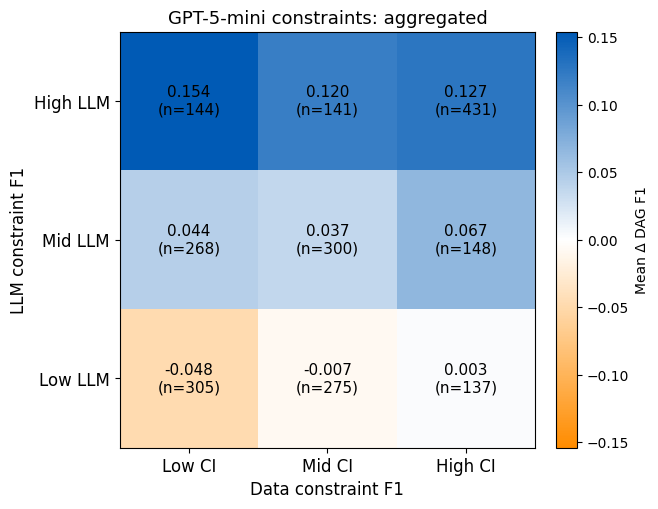

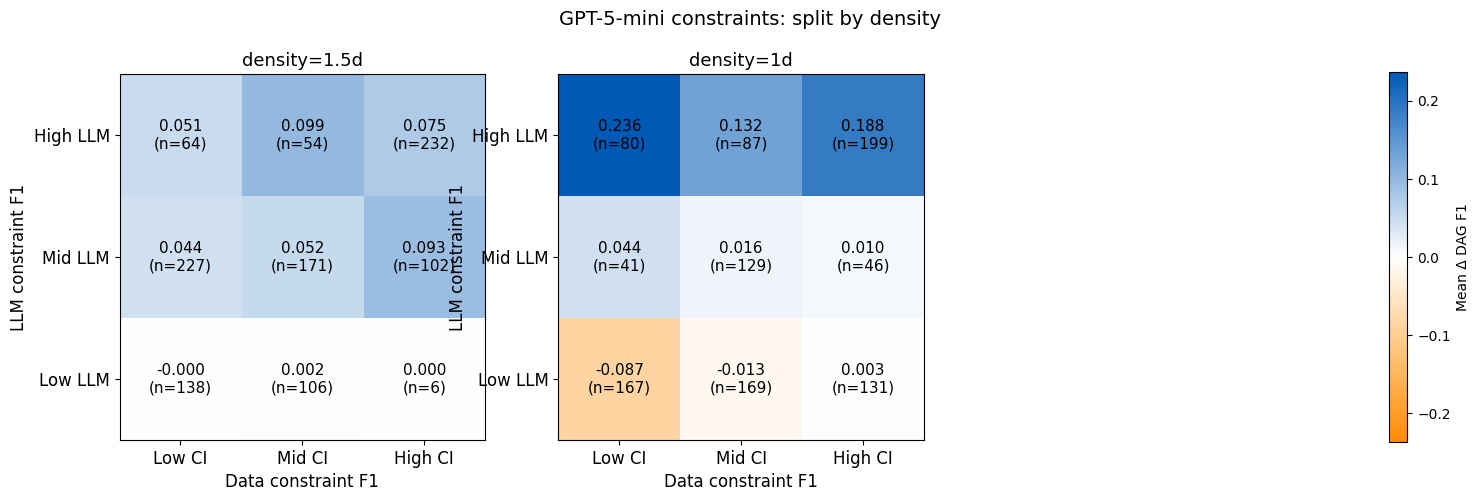

,dataset,seed,n_nodes,ci_quality,llm_quality,comb,ci,delta,size,type,density,ci_bin,llm_bin
0,dag_10_nodes_10_edges_degrees_ER,150,10.0,0.820084,0.012346,0.800000,0.82000,-0.020000,10,ER,1d,High,Low
1,dag_10_nodes_10_edges_degrees_ER,183,10.0,0.895833,0.012346,0.694720,0.63156,0.063160,10,ER,1d,High,Low
2,dag_10_nodes_10_edges_degrees_ER,304,10.0,0.793651,0.012346,0.821040,0.80000,0.021040,10,ER,1d,High,Low
3,dag_10_nodes_10_edges_degrees_ER,316,10.0,0.748663,0.012346,0.673680,0.54738,0.126300,10,ER,1d,Mid,Low
4,dag_10_nodes_10_edges_degrees_ER,359,10.0,0.813725,0.012346,0.778940,0.80000,-0.021060,10,ER,1d,High,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2145,dag_5_nodes_7_edges_semantics_random,8266,5.0,0.969072,0.271429,0.461533,0.43076,0.030773,5,LT,1.5d,High,High
2146,dag_5_nodes_7_edges_semantics_random,8289,5.0,0.677419,0.271429,0.583350,0.16670,0.416650,5,LT,1.5d,Mid,High
2147,dag_5_nodes_7_edges_semantics_random,8328,5.0,0.931034,0.271429,0.461533,0.49230,-0.030767,5,LT,1.5d,High,High
2148,dag_5_nodes_7_edges_semantics_random,8823,5.0,0.482759,0.271429,0.666700,0.75000,-0.083300,5,LT,1.5d,Mid,High


In [9]:
run_interaction_heatmaps(RUNS['GPT-5-mini constraints'], 'GPT-5-mini constraints', split_by='density', global_bins=True)

## Gemini Constraints Reference

Run these cells when you want the original Gemini constraints side-by-side for comparison.

In [10]:
gemini_table = build_run_table(RUNS['Gemini constraints'])
display(gemini_table.groupby(['size', 'type'])['delta'].agg(['count', 'mean', 'std']).reset_index())

,size,type,count,mean,std
0,5,ER,250,0.092701,0.165200
1,5,LT,300,0.241161,0.165939
2,5,SF,300,0.102479,0.221615
3,10,ER,300,0.039669,0.226003
4,10,LT,249,0.042798,0.115427
5,10,SF,300,0.037429,0.094349
6,15,ER,300,0.041181,0.085786
7,15,LT,300,0.035376,0.091169
8,15,SF,300,-0.010174,0.060299


Gemini constraints: 2599 matched run rows, 52 datasets
CI edges (rank space): [0.00038476337052712584, 0.3335898422470181, 0.666794921123509, 1.0]
LLM edges (rank space): [0.00038476337052712584, 0.3335898422470181, 0.666794921123509, 1.0]


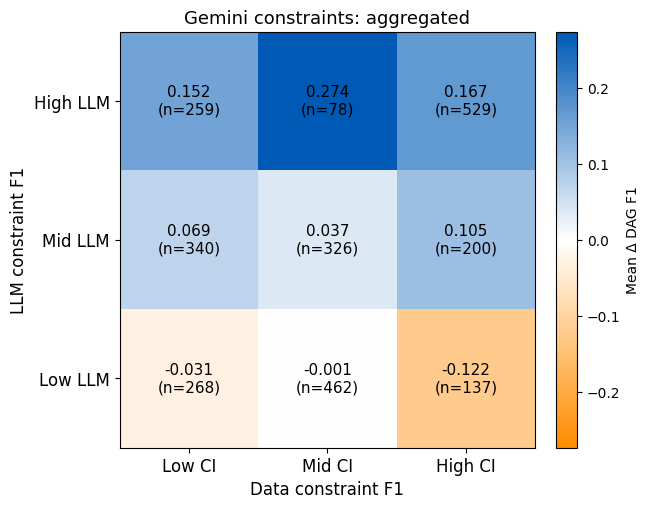

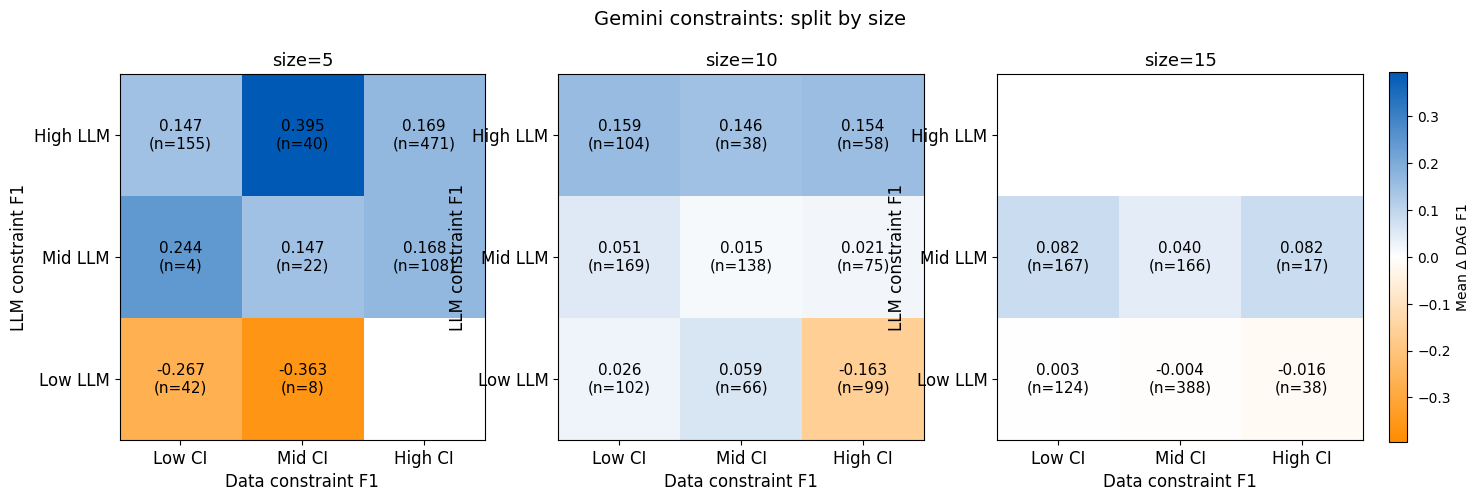

,dataset,seed,n_nodes,ci_quality,llm_quality,comb,ci,delta,size,type,density,ci_bin,llm_bin
0,dag_10_nodes_10_edges_degrees_ER,150,10.0,0.820084,0.139785,0.88000,0.88000,0.000000e+00,10,ER,1d,High,Low
1,dag_10_nodes_10_edges_degrees_ER,183,10.0,0.895833,0.139785,0.65262,0.65262,1.110223e-16,10,ER,1d,High,Low
2,dag_10_nodes_10_edges_degrees_ER,304,10.0,0.793651,0.139785,0.84210,0.80000,4.210000e-02,10,ER,1d,High,Low
3,dag_10_nodes_10_edges_degrees_ER,316,10.0,0.748663,0.139785,0.65262,0.54738,1.052400e-01,10,ER,1d,Mid,Low
4,dag_10_nodes_10_edges_degrees_ER,359,10.0,0.813725,0.139785,0.84210,0.77894,6.316000e-02,10,ER,1d,High,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2645,dag_5_nodes_7_edges_semantics_random,8266,5.0,0.969072,0.653680,0.92310,0.49230,4.308000e-01,5,LT,1.5d,High,High
2646,dag_5_nodes_7_edges_semantics_random,8289,5.0,0.677419,0.653680,0.83330,0.16670,6.666000e-01,5,LT,1.5d,Mid,High
2647,dag_5_nodes_7_edges_semantics_random,8328,5.0,0.931034,0.653680,0.92310,0.49230,4.308000e-01,5,LT,1.5d,High,High
2648,dag_5_nodes_7_edges_semantics_random,8823,5.0,0.625000,0.653680,0.83330,0.33330,5.000000e-01,5,LT,1.5d,Mid,High


In [11]:
run_interaction_heatmaps(RUNS['Gemini constraints'], 'Gemini constraints', split_by='size', global_bins=True)

Gemini constraints: 2599 matched run rows, 52 datasets
CI edges (rank space): [0.00038476337052712584, 0.3335898422470181, 0.666794921123509, 1.0]
LLM edges (rank space): [0.00038476337052712584, 0.3335898422470181, 0.666794921123509, 1.0]


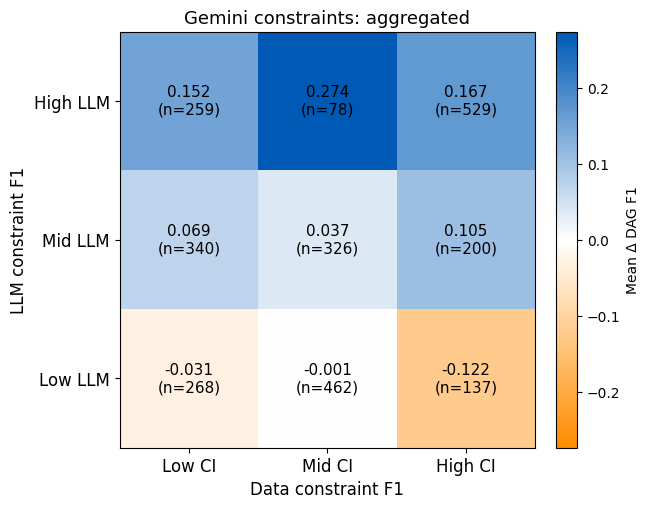

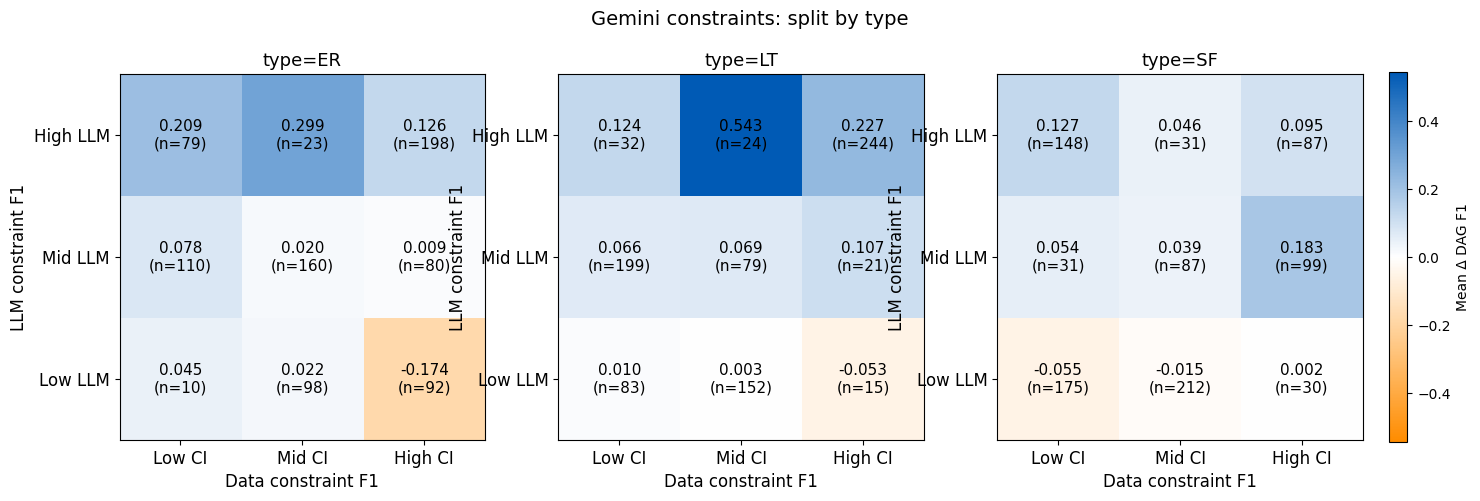

,dataset,seed,n_nodes,ci_quality,llm_quality,comb,ci,delta,size,type,density,ci_bin,llm_bin
0,dag_10_nodes_10_edges_degrees_ER,150,10.0,0.820084,0.139785,0.88000,0.88000,0.000000e+00,10,ER,1d,High,Low
1,dag_10_nodes_10_edges_degrees_ER,183,10.0,0.895833,0.139785,0.65262,0.65262,1.110223e-16,10,ER,1d,High,Low
2,dag_10_nodes_10_edges_degrees_ER,304,10.0,0.793651,0.139785,0.84210,0.80000,4.210000e-02,10,ER,1d,High,Low
3,dag_10_nodes_10_edges_degrees_ER,316,10.0,0.748663,0.139785,0.65262,0.54738,1.052400e-01,10,ER,1d,Mid,Low
4,dag_10_nodes_10_edges_degrees_ER,359,10.0,0.813725,0.139785,0.84210,0.77894,6.316000e-02,10,ER,1d,High,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2645,dag_5_nodes_7_edges_semantics_random,8266,5.0,0.969072,0.653680,0.92310,0.49230,4.308000e-01,5,LT,1.5d,High,High
2646,dag_5_nodes_7_edges_semantics_random,8289,5.0,0.677419,0.653680,0.83330,0.16670,6.666000e-01,5,LT,1.5d,Mid,High
2647,dag_5_nodes_7_edges_semantics_random,8328,5.0,0.931034,0.653680,0.92310,0.49230,4.308000e-01,5,LT,1.5d,High,High
2648,dag_5_nodes_7_edges_semantics_random,8823,5.0,0.625000,0.653680,0.83330,0.33330,5.000000e-01,5,LT,1.5d,Mid,High


In [12]:
run_interaction_heatmaps(RUNS['Gemini constraints'], 'Gemini constraints', split_by='type', global_bins=True)

Gemini constraints: 2599 matched run rows, 52 datasets
CI edges (rank space): [0.00038476337052712584, 0.3335898422470181, 0.666794921123509, 1.0]
LLM edges (rank space): [0.00038476337052712584, 0.3335898422470181, 0.666794921123509, 1.0]


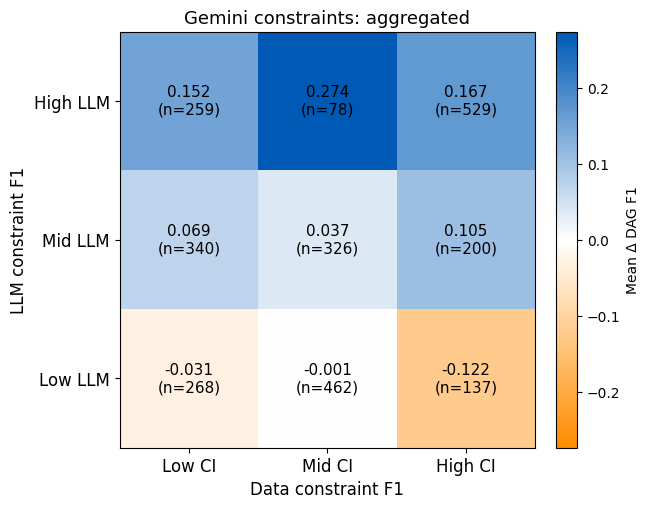

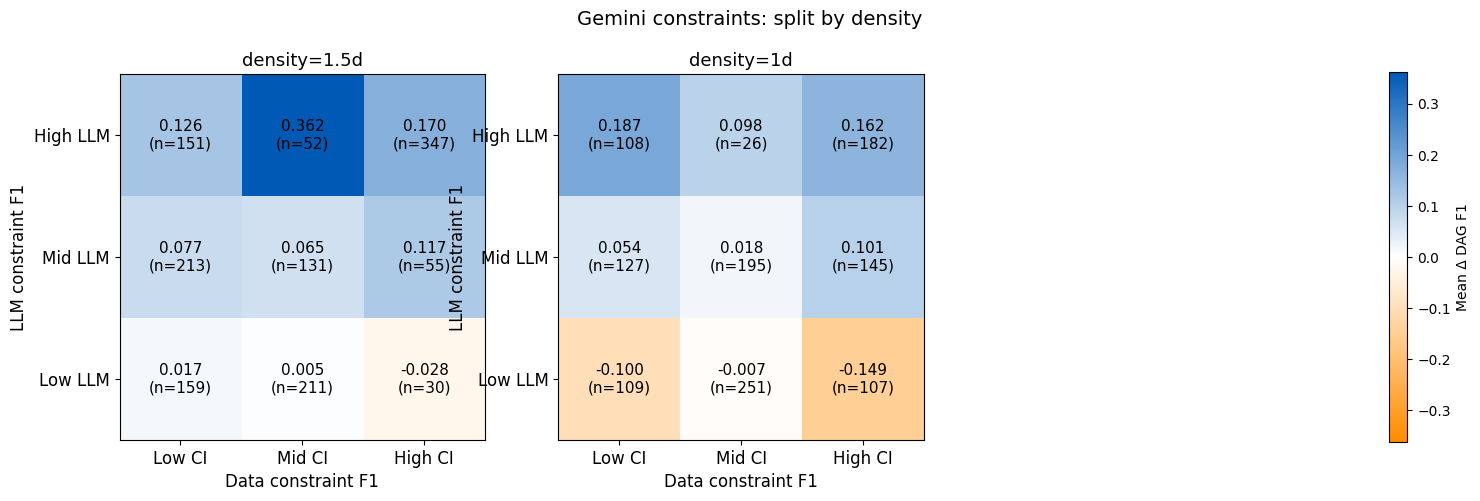

,dataset,seed,n_nodes,ci_quality,llm_quality,comb,ci,delta,size,type,density,ci_bin,llm_bin
0,dag_10_nodes_10_edges_degrees_ER,150,10.0,0.820084,0.139785,0.88000,0.88000,0.000000e+00,10,ER,1d,High,Low
1,dag_10_nodes_10_edges_degrees_ER,183,10.0,0.895833,0.139785,0.65262,0.65262,1.110223e-16,10,ER,1d,High,Low
2,dag_10_nodes_10_edges_degrees_ER,304,10.0,0.793651,0.139785,0.84210,0.80000,4.210000e-02,10,ER,1d,High,Low
3,dag_10_nodes_10_edges_degrees_ER,316,10.0,0.748663,0.139785,0.65262,0.54738,1.052400e-01,10,ER,1d,Mid,Low
4,dag_10_nodes_10_edges_degrees_ER,359,10.0,0.813725,0.139785,0.84210,0.77894,6.316000e-02,10,ER,1d,High,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2645,dag_5_nodes_7_edges_semantics_random,8266,5.0,0.969072,0.653680,0.92310,0.49230,4.308000e-01,5,LT,1.5d,High,High
2646,dag_5_nodes_7_edges_semantics_random,8289,5.0,0.677419,0.653680,0.83330,0.16670,6.666000e-01,5,LT,1.5d,Mid,High
2647,dag_5_nodes_7_edges_semantics_random,8328,5.0,0.931034,0.653680,0.92310,0.49230,4.308000e-01,5,LT,1.5d,High,High
2648,dag_5_nodes_7_edges_semantics_random,8823,5.0,0.625000,0.653680,0.83330,0.33330,5.000000e-01,5,LT,1.5d,Mid,High


In [13]:
run_interaction_heatmaps(RUNS['Gemini constraints'], 'Gemini constraints', split_by='density', global_bins=True)